# **Análisis fallecidos por Covid19 en Colombia**

In [1]:
#Se cargan las librerias necesarias

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Se carga la base de datos mediante enlace
ruta = "https://www.datos.gov.co/resource/jp5m-e7yr.csv?$limit=500000"
df = pd.read_csv(ruta)
df.head()

,fecha_reporte_web,id_de_caso,fecha_de_notificaci_n,departamento,departamento_nom,ciudad_municipio,ciudad_municipio_nom,edad,unidad_medida,sexo,...,pais_viajo_1_cod,pais_viajo_1_nom,recuperado,fecha_inicio_sintomas,fecha_muerte,fecha_diagnostico,fecha_recuperado,tipo_recuperacion,per_etn_,nom_grupo_
0,2020-12-24 00:00:00,1556982,2020-12-22 00:00:00,76,VALLE,76001,CALI,74,1,F,...,NaN,NaN,Fallecido,2020-12-17 00:00:00,2020-12-30 00:00:00,2020-12-23 00:00:00,NaN,NaN,6,NaN
1,2020-12-24 00:00:00,1556986,2020-12-18 00:00:00,76,VALLE,76001,CALI,66,1,F,...,NaN,NaN,Fallecido,2020-12-11 00:00:00,2020-12-26 00:00:00,2020-12-22 00:00:00,NaN,NaN,6,NaN
2,2020-11-08 00:00:00,1137434,2020-11-05 00:00:00,11,BOGOTA,11001,BOGOTA,81,1,F,...,NaN,NaN,Fallecido,2020-10-31 00:00:00,2020-11-11 00:00:00,2020-11-07 00:00:00,NaN,NaN,6,NaN
3,2020-11-08 00:00:00,1137440,2020-11-03 00:00:00,63,QUINDIO,63001,ARMENIA,85,1,F,...,NaN,NaN,Fallecido,2020-10-31 00:00:00,2020-11-12 00:00:00,2020-10-31 00:00:00,NaN,NaN,6,NaN
4,2020-11-08 00:00:00,1137443,2020-11-04 00:00:00,11,BOGOTA,11001,BOGOTA,78,1,M,...,NaN,NaN,Fallecido,2020-10-31 00:00:00,2020-11-16 00:00:00,2020-11-07 00:00:00,NaN,NaN,6,NaN


In [3]:
#Se visualiza información general de la base de datos - está compuesta de 23 columnas y 143124 registros, además de los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143125 entries, 0 to 143124
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   fecha_reporte_web      143125 non-null  object 
 1   id_de_caso             143125 non-null  int64  
 2   fecha_de_notificaci_n  143125 non-null  object 
 3   departamento           143125 non-null  int64  
 4   departamento_nom       143125 non-null  object 
 5   ciudad_municipio       143125 non-null  int64  
 6   ciudad_municipio_nom   143125 non-null  object 
 7   edad                   143125 non-null  int64  
 8   unidad_medida          143125 non-null  int64  
 9   sexo                   143125 non-null  object 
 10  fuente_tipo_contagio   143125 non-null  object 
 11  ubicacion              143125 non-null  object 
 12  estado                 143125 non-null  object 
 13  pais_viajo_1_cod       94 non-null      float64
 14  pais_viajo_1_nom       94 non-null  

In [4]:
#Se revisan si hay filas repetidas en la base de datos y no se identifica ninguna
duplicadas = df.duplicated().sum()
duplicadas

np.int64(0)

In [5]:
#Se revisan cuantos datos faltantes hay por cada columna, identificandose que pais_viajo_1_cod, pais_viajo_1_nom, fecha_recuperacion, tipo_recuperacion
#y nom_grupo tienen la mayor parte de datos faltantes, por lo que seran eliminadas:
df.isnull().sum()

,0
fecha_reporte_web,0
id_de_caso,0
fecha_de_notificaci_n,0
departamento,0
departamento_nom,0
ciudad_municipio,0
ciudad_municipio_nom,0
edad,0
unidad_medida,0
sexo,0


In [6]:
#Se eliminan las columnas mencionadas anteriormente

columnas_a_eliminar = ["pais_viajo_1_cod", "pais_viajo_1_nom", "fecha_recuperado", "tipo_recuperacion", "nom_grupo_" ]

df = df.drop(columns=columnas_a_eliminar)


#se visualizan las columnas restantes
print(df.columns)

Index(['fecha_reporte_web', 'id_de_caso', 'fecha_de_notificaci_n',
       'departamento', 'departamento_nom', 'ciudad_municipio',
       'ciudad_municipio_nom', 'edad', 'unidad_medida', 'sexo',
       'fuente_tipo_contagio', 'ubicacion', 'estado', 'recuperado',
       'fecha_inicio_sintomas', 'fecha_muerte', 'fecha_diagnostico',
       'per_etn_'],
      dtype='object')


In [11]:
#Se revisan los valores unicos por cada columna
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

fecha_reporte_web: 852 valores únicos
id_de_caso: 143125 valores únicos
fecha_de_notificaci_n: 1246 valores únicos
departamento: 36 valores únicos
departamento_nom: 38 valores únicos
ciudad_municipio: 1088 valores únicos
ciudad_municipio_nom: 1014 valores únicos
edad: 110 valores únicos
unidad_medida: 3 valores únicos
sexo: 3 valores únicos
fuente_tipo_contagio: 3 valores únicos
ubicacion: 1 valores únicos
estado: 1 valores únicos
recuperado: 2 valores únicos
fecha_inicio_sintomas: 1252 valores únicos
fecha_muerte: 1258 valores únicos
fecha_diagnostico: 1252 valores únicos
per_etn_: 5 valores únicos


In [14]:
#Se revisa cuales son los valores unicos que presenta codigo de departamento, puesto que con Bogotá deberian aparecer 33, pero registra 36
df['departamento'].unique()

array([   76,    11,    63,    50,     5,    68,    25,    52,    20,
          15,    44,    54,    47, 47001,    19,    17,    41,    81,
           8,    73,    27,  8001,    85,    23,    66,    94, 13001,
          18,    13,    70,    86,    91,    88,    95,    97,    99])

Se identifica que hay tres códigos (47001, 8001 y 13001) que corresponden a municipios, pero estan como departarmentos, por lo cual, serán cambios por su respectivo código de Departamento

In [15]:
#Se reemplazan los codigos de municipios por departamento
reemplazos = {
    47001: 47,
    8001: 8,
    13001: 13
}

df['departamento'] = df['departamento'].replace(reemplazos)

In [16]:
#Se comprueba que haya quedado bien
df['departamento'].unique()

array([76, 11, 63, 50,  5, 68, 25, 52, 20, 15, 44, 54, 47, 19, 17, 41, 81,
        8, 73, 27, 85, 23, 66, 94, 13, 18, 70, 86, 91, 88, 95, 97, 99])

In [12]:
#Se revisa cuales son los valores unicos que presenta nombre de departamento, puesto que registra 38
df['departamento_nom'].unique()

array(['VALLE', 'BOGOTA', 'QUINDIO', 'META', 'ANTIOQUIA', 'SANTANDER',
       'CUNDINAMARCA', 'NARIÑO', 'CESAR', 'BOYACA', 'GUAJIRA',
       'NORTE SANTANDER', 'MAGDALENA', 'STA MARTA D.E.', 'CAUCA',
       'CALDAS', 'HUILA', 'ARAUCA', 'ATLANTICO', 'TOLIMA', 'CHOCO',
       'BARRANQUILLA', 'CASANARE', 'CORDOBA', 'RISARALDA', 'GUAINIA',
       'CARTAGENA', 'CAQUETA', 'BOLIVAR', 'SUCRE', 'PUTUMAYO', 'AMAZONAS',
       'SAN ANDRES', 'GUAVIARE', 'VAUPES', 'VICHADA', 'Caldas',
       'Santander'], dtype=object)

Se identifica que un mismo departamento esta nombrado con mayusculas y minusculas (Santander y caldas) por lo cual, se procede a normalizar esa columna. Posteriormente, se cambiará el nombre de los municipios por los departamentos correspondientes.

In [17]:
#Se normaliza la columna nombre de departamento
df['departamento_nom'] = df['departamento_nom'].str.lower().str.strip()

In [18]:
#Se cambia de municipio a departamento
reemplazos1 = {
    'sta marta d.e.': 'magdalena',
    'barranquilla': 'atlantico',
    'cartagena': 'bolivar'
}

df['departamento_nom'] = df['departamento_nom'].replace(reemplazos1)

In [19]:
#Se comprueba que haya quedado bien
df['departamento_nom'].unique()

array(['valle', 'bogota', 'quindio', 'meta', 'antioquia', 'santander',
       'cundinamarca', 'nariño', 'cesar', 'boyaca', 'guajira',
       'norte santander', 'magdalena', 'cauca', 'caldas', 'huila',
       'arauca', 'atlantico', 'tolima', 'choco', 'casanare', 'cordoba',
       'risaralda', 'guainia', 'bolivar', 'caqueta', 'sucre', 'putumayo',
       'amazonas', 'san andres', 'guaviare', 'vaupes', 'vichada'],
      dtype=object)

In [20]:
#Se revisa porque en sexo hay tres (03) valores únicos identificando que masculino esta registrado con M y m
df['sexo'].unique()

array(['F', 'M', 'm'], dtype=object)

In [21]:
#Se normaliza la columna sexo
df['sexo'] = df['sexo'].str.lower().str.strip()

In [22]:
#Se comprueba que haya quedado bien
df['sexo'].unique()

array(['f', 'm'], dtype=object)

### **Casos por departamento**

In [27]:
casos_por_dpto = df.groupby('departamento_nom').size().reset_index(name='casos')
print(casos_por_dpto)

   departamento_nom  casos
0          amazonas    265
1         antioquia  18717
2            arauca    588
3         atlantico  10257
4            bogota  30293
5           bolivar   3284
6            boyaca   2922
7            caldas   2588
8           caqueta   1049
9          casanare   1030
10            cauca   1866
11            cesar   2699
12            choco    432
13          cordoba   4001
14     cundinamarca   7431
15          guainia     37
16          guajira   1554
17         guaviare    105
18            huila   3599
19        magdalena   3680
20             meta   2622
21           nariño   3439
22  norte santander   5211
23         putumayo    793
24          quindio   2090
25        risaralda   2523
26       san andres    157
27        santander   8431
28            sucre   1759
29           tolima   4108
30            valle  15508
31           vaupes     22
32          vichada     65


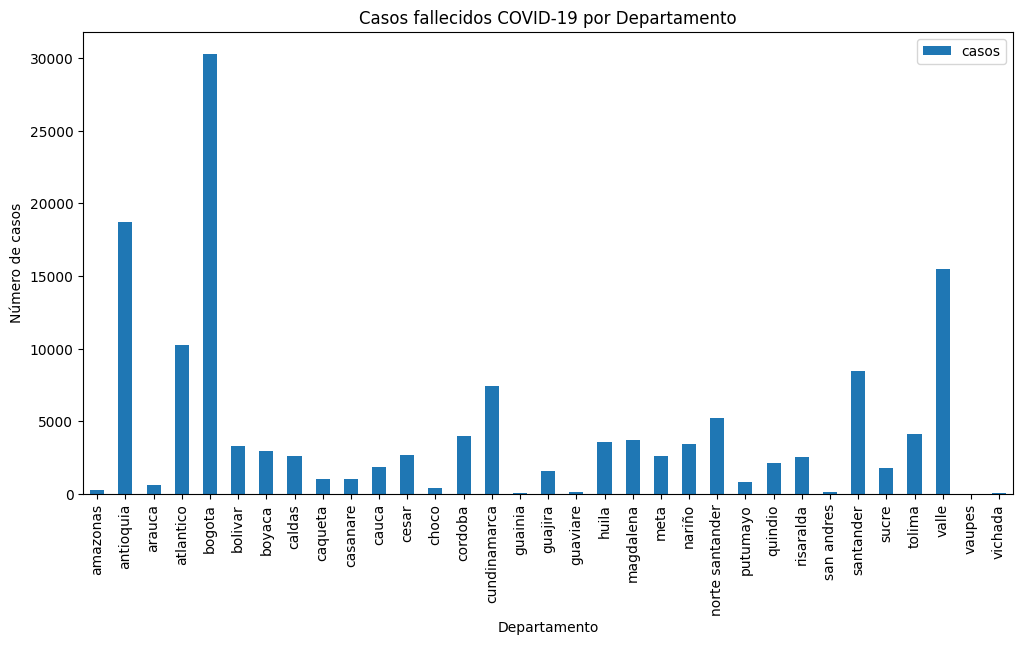

In [30]:
casos_por_dpto.plot(x='departamento_nom', y='casos', kind='bar', figsize=(12,6))
plt.title("Casos fallecidos COVID-19 por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Número de casos")
plt.xticks(rotation=90)
plt.show()





Bogotá, Antioquia y Valle fueron los lugares que más reportaron casos de fallecidos por covid19

###**Casos por sexo**

In [31]:
casos_por_sexo= df.groupby('sexo').size().reset_index(name='casos')
print(casos_por_sexo)

  sexo  casos
0    f  56383
1    m  86742


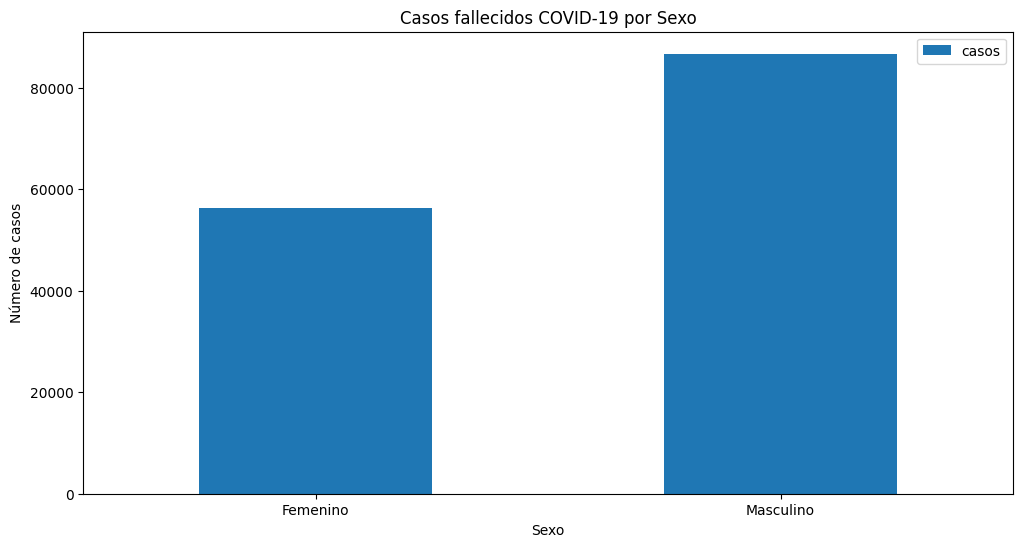

In [34]:
casos_por_sexo.plot(x='sexo', y='casos', kind='bar', figsize=(12,6))
plt.title("Casos fallecidos COVID-19 por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.xticks(ticks=[0,1], labels=['Femenino', 'Masculino'], rotation=0)
plt.show()





Se presentaron más fallecimientos por Covid19 de sexo masculino que femenino

###**Casos de fallecimientos en el tiempo**

In [35]:
#Teniendo en cuenta que fecha de muerte la toma como object se pasa para que se tome como fecha
df['fecha_muerte'] = pd.to_datetime(df['fecha_muerte'])

In [37]:
print(df['fecha_muerte'].dtype)

datetime64[ns]


In [38]:
#casos por día
casos_por_dia = df.groupby('fecha_muerte').size().reset_index(name='num_casos')

In [45]:
import plotly.express as px

fig = px.line(casos_por_dia,
              x='fecha_muerte',
              y='num_casos',
              title='Fallecimientos diarios de COVID-19',
              labels={'fecha':'Fecha', 'num_casos':'Número de casos'},
              markers=True)  # agrega puntos para poder hacer hover

fig.update_traces(mode='lines+markers')  # líneas con puntos
fig.update_layout(xaxis_title='Fecha', yaxis_title='Número de casos')

fig.show()

Se visualiza que el pico más alto de fallecimientos por Covid19 en Colombia se presentó en junio 2021, fecha en la que coincidió con la circulación de sepas más contagiosas (Alfa y Gamma), se habian presentado aglomeraciones por el paro nacional y la relajación de las medidas de autocuidado. Ademas este pico fue considerado el más complejo, con una alta ocupación de Unidades de Cuidados Intensivos (UCI), congestionando el sistema de salud.